# Washington's December floods, 2025, step by step

A walkthrough of how this forge3d animation is made, using the project's own scripts (`scripts/config.py`, `drape.py`, `render.py`, `finish.py`). The film shows the rain and the rivers across Washington from 1 to 20 December 2025, hour by hour, draped over Washington's terrain.

1. The canvas: Washington's terrain, and the trick that fits a whole state inside the viewer's camera
2. The data
3. From data to a colour drape for any moment
4. Frames, rendered and finished by the project's own pipeline

## Setup

Run `pixi run stills` once first so everything is downloaded into `data/`. Sections 1–3 need no renderer; section 4 opens forge3d's viewer (a GPU, or on Linux Mesa's software Vulkan under `xvfb-run`). It writes into `out/notebook/` and leaves the film in `out/` alone.

In [1]:
STILLS = "200,250,end"   # two moments in the first atmospheric river, and the final hold with the record crests, as in `pixi run stills`
LITE = True              # lighter shadows and antialiasing (render.py --lite): much faster on a CPU

In [2]:
import json, math, sys, time
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from PIL import Image
from IPython.display import Image as Show, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts" / "drape.py").exists())
sys.path.insert(0, str(ROOT / "scripts"))
import config, drape, render
import forge3d as f3d

%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"pil_kwargs": {"quality": 85}, "bbox_inches": "tight"}
plt.rcParams.update({"figure.dpi": 100, "font.size": 9})
print("forge3d", f3d.__version__)

forge3d 1.40.1


## 1. The canvas

All four Washington animations share one canvas: USGS 3DEP elevation resampled to 250 m in UTM zone 10N, from Portland to the Canadian border, with the state outline from Natural Earth. In 3D it's exaggerated 3.5× (the state is about 600 km wide, so true scale would be flat) and lightly smoothed so ridges read as ridges rather than needles.

**Fitting a state in the camera.** forge3d's viewer caps the camera distance at 50 km: plenty for one mountain, not for a whole state. So `render.scaled_dem` hands the viewer a copy of the DEM with every coordinate multiplied by a world scale (same pixels, smaller numbers), and the height exaggeration is scaled to match. The picture is identical and the camera stays inside its limit; `finish.py` uses the same scale to put the city labels in the right place.

DEM 2628 x 1659 at 250 m = 657 x 415 km, -3-4367 m
world scale 0.0685: the viewer sees a 45 km-wide state, with heights exaggerated 3.5 x 0.0685 = 0.2397
the viewer meshes it as a 1659 x 1659 grid: a vertex every 396 m east-west and 250 m north-south


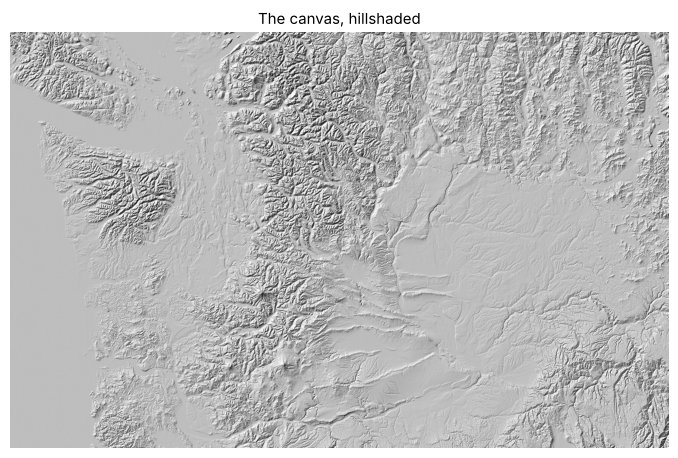

In [3]:
with rasterio.open(config.DEM) as src:
    dem = src.read(1); tf = src.transform
h, w = dem.shape
width_m = w * tf.a
s = render.WORLD_WIDTH_M / width_m
print(f"DEM {w} x {h} at {tf.a:g} m = {width_m / 1000:.0f} x {h * -tf.e / 1000:.0f} km, {dem.min():.0f}-{dem.max():.0f} m")
print(f"world scale {s:.4f}: the viewer sees a {render.WORLD_WIDTH_M / 1000:.0f} km-wide state, "
      f"with heights exaggerated {config.EXAGGERATION} x {s:.4f} = {config.EXAGGERATION * s:.4f}")
n = min(2048, h, w)      # the viewer's log: a square mesh, at most 2048 a side and no more than the DEM's shorter side
print(f"the viewer meshes it as a {n} x {n} grid: a vertex every {width_m / (n - 1):.0f} m east-west and "
      f"{h * -tf.e / (n - 1):.0f} m north-south")
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.imshow(LightSource(azdeg=315, altdeg=35).hillshade(np.where(dem <= 0.5, 0, dem), vert_exag=3, dx=tf.a, dy=-tf.e), cmap="gray")
ax.set_title("The canvas, hillshaded"); ax.axis("off"); plt.show()

## 2. The data: rain and rivers

- **Rain** is NOAA **HRRR**'s hourly precipitation on its 3 km grid, byte-range downloaded from the open-data bucket on AWS.
- **Rivers** are every HydroRIVERS reach draining at least 150 km².
- **Flow** is from **USGS gauges**: 15-minute flow averaged to hours, each gauge's daily median for the date (its "normal"), and its annual peaks (its record).

A strong atmospheric river stalled over the state on 8–11 December and a second storm followed on 15–18 December. Here are the gauges with at least 20 years of record that beat their own record crest. Not all of them light up in the film: a gauge has to be matched to a mapped river reach (within 3 km), and only the biggest rivers get a label.

rain: 480 hours on a 234 x 281 grid; gauges: 307
9 gauges with 20+ years of record passed their record peak:
  SNOQUALMIE RIVER NEAR CARNATION, WA          peak    88,900 cfs, old record    82,900 (2009, 95 yrs)
  MF NOOKSACK RIVER NEAR DEMING, WA            peak    19,867 cfs, old record    18,900 (2015, 46 yrs)
  CEDAR RIVER AT RENTON, WA                    peak    11,650 cfs, old record    10,600 (1990, 80 yrs)
  RUBY CREEK BELOW PANTHER CREEK NEAR NEWHALEM peak    10,072 cfs, old record     9,160 (2021, 22 yrs)
  CEDAR RIVER BELOW DIVERSION NEAR LANDSBURG,  peak     9,085 cfs, old record     7,790 (2009, 34 yrs)
  SKOOKUM CREEK ABOVE DIVERSION NEAR WICKERSHA peak     7,105 cfs, old record     5,850 (2003, 26 yrs)
  RAGING RIVER NEAR FALL CITY, WA              peak     6,595 cfs, old record     6,220 (1990, 79 yrs)
  CEDAR RIVER AT POWERPLANT AT CEDAR FALLS, WA peak     6,280 cfs, old record     3,740 (2009, 24 yrs)
  ISSAQUAH CREEK NEAR HOBART, WA               peak     1,472 cfs, 

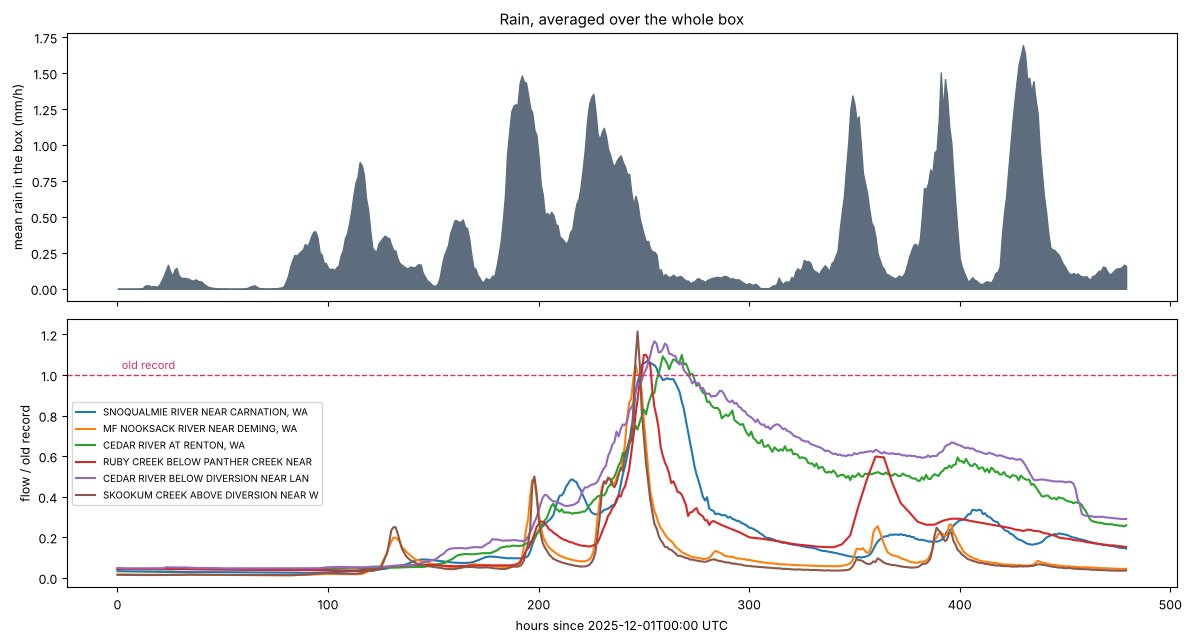

In [4]:
g = np.load(config.GAUGES)
r = np.load(config.RAIN)
flow, rec, recn = g["flow"], g["record"], g["record_n"]
tu = g["times_utc"]
print(f"rain: {r['rain'].shape[0]} hours on a {r['rain'].shape[1]} x {r['rain'].shape[2]} grid; gauges: {flow.shape[1]}")
peak = np.nanmax(flow, axis=0)
broke = np.where(np.isfinite(rec) & (recn >= config.RECORD_MIN_YEARS) & (peak > rec))[0]
print(f"{len(broke)} gauges with {config.RECORD_MIN_YEARS}+ years of record passed their record peak:")
for k in broke[np.argsort(-peak[broke])]:
    print(f"  {g['name'][k][:44]:44} peak {peak[k]:9,.0f} cfs, old record {rec[k]:9,.0f} ({g['record_year'][k]}, {recn[k]} yrs)")
fig, axs = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
hrs = np.arange(flow.shape[0])
statewide = r["rain"].astype(np.float32).mean(axis=(1, 2))
axs[0].fill_between(hrs, 0, statewide, color="#5d6d7e"); axs[0].set_ylabel("mean rain in the box (mm/h)")
axs[0].set_title("Rain, averaged over the whole box")
for k in broke[np.argsort(-peak[broke])][:6]:
    axs[1].plot(hrs, flow[:, k] / rec[k], label=g["name"][k][:36])
axs[1].axhline(1, color="#d6336c", lw=1, ls="--"); axs[1].text(2, 1.03, "old record", color="#d6336c", fontsize=8)
axs[1].set_ylabel("flow / old record"); axs[1].set_xlabel(f"hours since {str(tu[0])} UTC"); axs[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Drawing rivers and rain

Each river reach takes the reading of the first gauge downstream of it, and is coloured by that gauge's flow as a multiple of its usual flow for the date: dim blue below normal, bright blue at normal, cyan then white at 3×, 10× and 30×, and **hot pink** once the gauge has passed its own record. Flooding reaches swell wider and glow.

Rain is drawn like the smoke in the smoke project: a second render pass carries it colour-coded (red for rain, blue for none), and `finish.py` turns the ratio back into a blue-grey veil sweeping in off the Pacific. Here's the land-and-rivers drape and the rain for one hour:

  5,732 river reaches; 232 of 307 gauges matched; 4,702 reaches take a gauge's reading


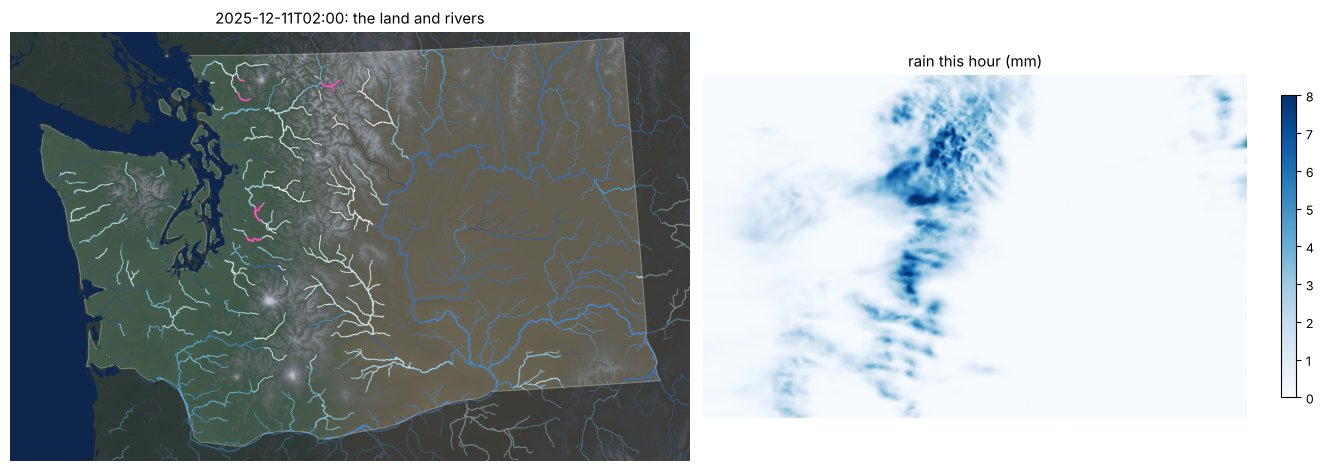

In [5]:
dr = drape.Drape(water_key=False)
H = 250
land, mm = dr.image(H, rain=False)
fig, axs = plt.subplots(1, 2, figsize=(14, 4.6))
axs[0].imshow(land); axs[0].set_title(f"{dr.time_label(H)}: the land and rivers")
im = axs[1].imshow(mm, cmap="Blues", vmin=0, vmax=8); axs[1].set_title("rain this hour (mm)")
plt.colorbar(im, ax=axs[1], shrink=0.7)
for a in axs: a.axis("off")
plt.tight_layout(); plt.show()

## 4. Frames

The camera sits south of the state looking north, 45° down, and swings slowly round toward the south-west over the course of the film. Each frame is two snapshots from the same camera: the land-and-rivers drape, then the rain code. `finish.py` then paints a dark sky, swaps the key-green water for deep blue, and adds the title, the clock and timeline, the city readings (projected with the viewer's own camera maths and faded out if they'd collide) and the legend.

Rather than re-implement any of that here, this runs the project's own `render.py --stills` with its output pointed at `out/notebook/`.

In [6]:
nb_out = config.OUT / "notebook"
config.OUT = nb_out                                        # viewer.log and work files
config.out_dir = lambda fmt: nb_out                        # frames/ and final/
config.video_path = lambda fmt: nb_out / "stills.mp4"      # leaves the film alone
nb_out.mkdir(parents=True, exist_ok=True)
argv = ["render.py", "--stills", STILLS] + (["--lite"] if LITE else [])
import contextlib, io
t0 = time.time()
log = io.StringIO()
old, sys.argv = sys.argv, argv
try:
    with contextlib.redirect_stdout(log):
        render.main()
finally:
    sys.argv = old
for line in log.getvalue().replace("\r", "\n").splitlines():
    if line.strip() and not line.startswith(("Video", "  finishing")) and "frame " not in line:
        print(line.strip())
finals = sorted((nb_out / "final").glob("frame_*.png"))
print(f"\n{len(finals)} finished frames in {time.time() - t0:.0f} s")

Preparing the land, rivers and rain...
5,732 river reaches; 232 of 307 gauges matched; 4,702 reaches take a gauge's reading
Previewing 3 frames (479 hours at 2 frames an hour)...
Finishing 3 frames on 1 worker(s)...

3 finished frames in 107 s


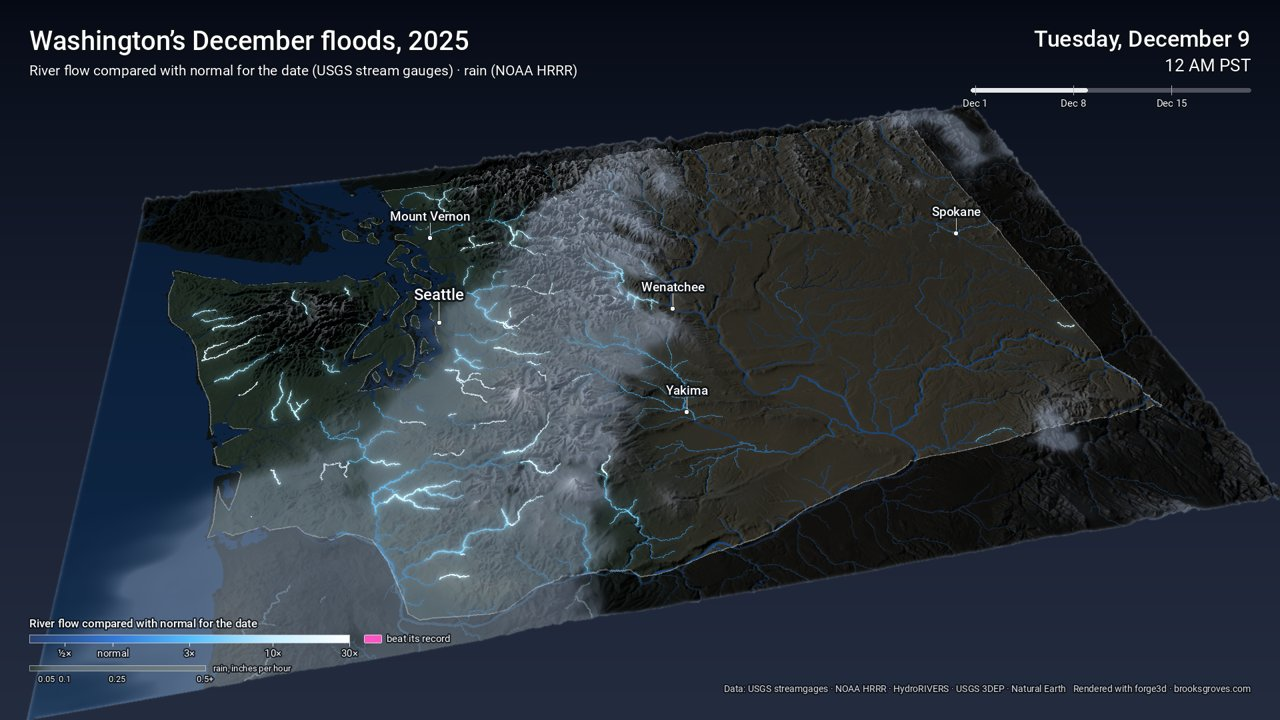

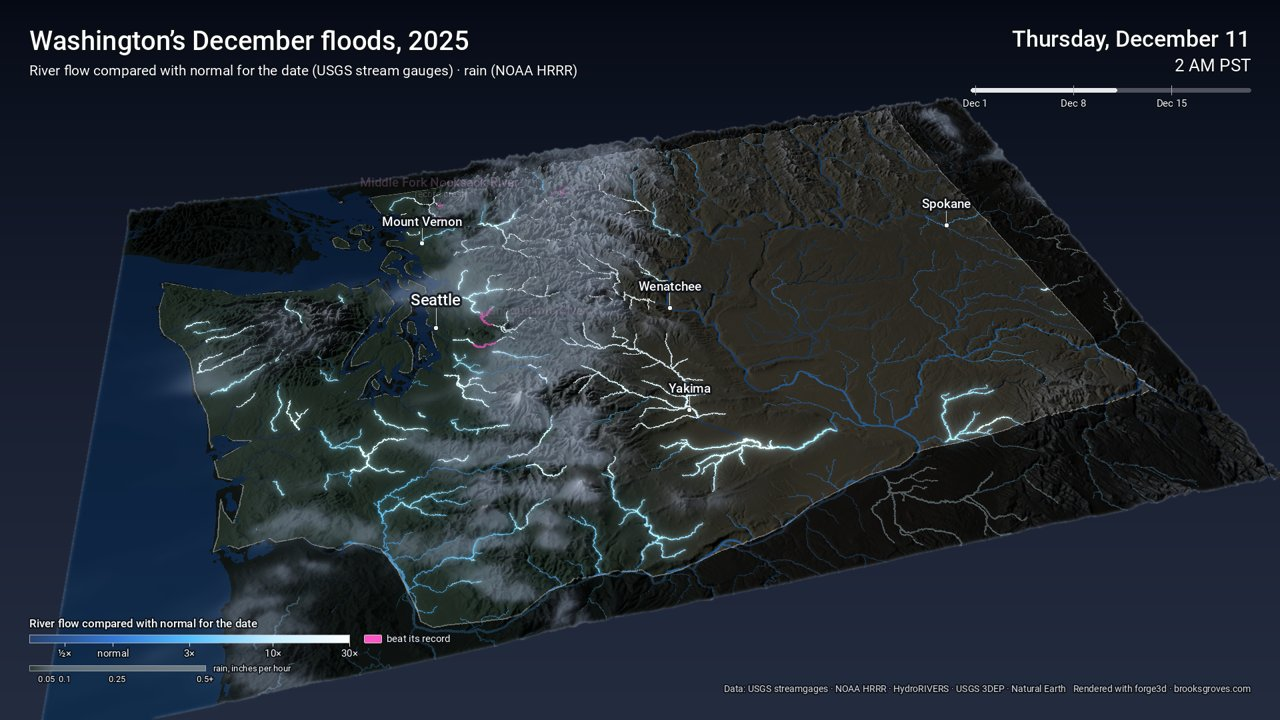

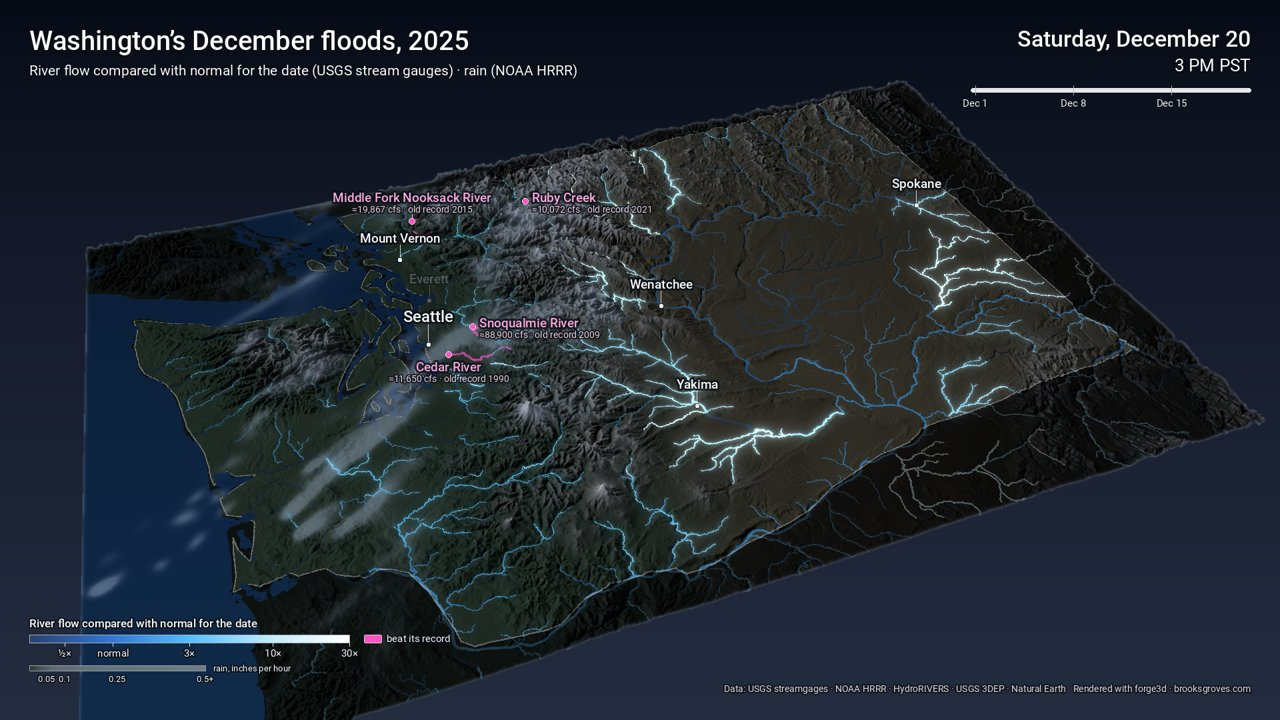

In [7]:
for p in finals:
    im = Image.open(p).convert("RGB")
    im.thumbnail((1280, 1280))
    q = p.with_suffix(".jpg"); im.save(q, quality=85)
    display(Show(filename=str(q), width=960))

## Caveats

- "Normal" is the USGS daily median for that calendar day; early December medians are low on rain-fed rivers, so moderate storms already read several times normal.
- Flows are hourly averages of 15-minute readings, a little below the true instantaneous crest, so the record test is conservative.
- Ungauged reaches take the nearest gauge downstream.

The film is `pixi run render` (16:9), with `render-square` and `render-portrait` cuts for social.

Data: NOAA HRRR · USGS Water Services · HydroRIVERS · USGS 3DEP · Natural Earth. Rendering: [forge3d](https://github.com/milos-agathon/forge3d) by Milos Popovic, whose wildfire smoke and temperature animations inspired these.